<a id="top"></a>
# Estimating Galaxy Cluster Masses with Convolutional Neural Networks

***

## Imports
This notebook uses the following:
- *numpy* to handle array functions
- *astropy.io fits* for accessing FITS files
- *matplotlib.pyplot* for plotting data
- *keras* for building the CNN

In [2]:
%matplotlib widget
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
import pandas as pd
import keras
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from keras.models import Sequential
from keras.layers import Input, Dense, Dropout, Conv2D, MaxPooling2D
from keras.layers import GlobalAveragePooling2D


## Learning Goals


**In this tutorial, you will see an example of building, compiling, and training a CNN on simulated astronomical data.**  By the end of this tutorial you will have a working example of a simple Convolutional Neural Network (CNN) in Keras.  This CNN can be adapted for any machine learning task that inputs an image and learns a continuous-valued label (regression). 

## Introduction
Convolutional Neural Networks (CNNs) are a class of machine learning (ML) algorithms that can extract information from images.  In this notebook, you will walk through the basic steps of applying a CNN to data:
1. Load the data and visualize a sample of the data
2. Divide the data into training, validation, and testing sets.
3. Build a CNN in Keras
4. Compile the CNN
5. Train the CNN to perform a regression task
6. Evaluate the results.

CNNs can be applied to a wide range of image recognition tasks, and while they are often used for image classification, this notebook builds a CNN for an image regression task.  Here, we will build, compile, and train CNN to estimate galaxy cluster log(masses) from simulated single-band (or _monochromatic_) X-ray images of galaxy clusters.


We will do it in three approch to reach to implementation in the paper. The standard approch is the one shared with us from a3Net team.

# Approch 1

## Cluster Mass Regression

This notebook trains a CNN to estimate cluster mass from X-ray images. The key evaluation unit is the cluster, not an individual image, because each cluster has up to three lines of sight.

### 1. Load the data

The FITS file contains the X-ray images and metadata, including `cluster_id`, `view_los`, `log_M500`, and the original train/validation/test flags.

In [3]:
filename = r'/Users/tripathimihir/Documents/a3net_2026/Cluster Mass Hack/cluster_TNG_data.fits'
hdul = fits.open(filename)
image_size = hdul[1].data.shape[1]

### 2. Prepare the baseline split

The original split is retained for the baseline model. The cross-validation model below uses cluster-level folds instead, preventing different views of one cluster from appearing in both training and validation data.

In [4]:
train_ind = np.argwhere(hdul[2].data['train'] == 1)
train_X = hdul[1].data[train_ind].reshape(-1, image_size, image_size, 1)
train_Y = hdul[2].data['log_M500'][train_ind]

val_ind = np.argwhere(hdul[2].data['validate'] == 1)
val_X = hdul[1].data[val_ind].reshape(-1, image_size, image_size, 1)
val_Y = hdul[2].data['log_M500'][val_ind]

test_ind = np.argwhere(hdul[2].data['test'] == 1)
test_X = hdul[1].data[test_ind].reshape(-1, image_size, image_size, 1)
test_Y = hdul[2].data['log_M500'][test_ind]

ML models often converge faster when the output is _roughly_ between 0 and 1. Next, let's perform a normalization that will speed up the training process a bit -- calculate the minimum log(mass) and subtract it from the Y labels as a change of units.  We'll put it back, later in the notebook, just before we plot the results.  

We can simply subtract off a constant value because our output doesn't have a large dynamical range, but there may be cases where you want to handle this more carefully and force all of your labels to be strictly in the (0,1) interval.  

In [5]:
norm = np.nanmin(hdul[2].data['log_M500'])
train_Y -= norm
val_Y -= norm
test_Y -= norm

### 3. Build a CNN in Keras

Here, we will build the model described in Section 2.2 of [Ntampaka et al., 2019](https://ui.adsabs.harvard.edu/abs/2019ApJ...876...82N/abstract)

Further details about Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dropout, and Dense layers can be found in the [Keras Layers Documentation](https://keras.io/api/layers/).  Further details about the relu activation function can be found in the [Keras Activation Function Documentation](https://keras.io/api/layers/activations/).

In [18]:
input_shape = (image_size, image_size, 1)
model = Sequential([
    Input(shape=input_shape),
    Conv2D(16, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(32, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    GlobalAveragePooling2D(),
    Dropout(0.1),
    Dense(200, activation='relu'),
    Dropout(0.1),
    Dense(100, activation='relu'),
    Dense(20, activation='relu'),
    Dense(1, activation='linear')
])

### 4. Compile the CNN

Next, we compile the model.  As in [Ntampaka et al., 2019](https://ui.adsabs.harvard.edu/abs/2019ApJ...876...82N/abstract), we select the Adam opmimizer (with a learning rate that is slightly decreased from the default rate) and the mean squared error loss function.

You can learn more about [optimizers](https://keras.io/api/optimizers/) and more about [loss functions for regression tasks](https://keras.io/api/losses/) in the [Keras documentation](https://keras.io/)

In [6]:
model.compile(loss='mean_squared_error', optimizer=keras.optimizers.Adam(learning_rate=0.0002))

### 5. Train the CNN to perform a regression task

We will start with training for 5 epochs, but this almost certainly won't be long enough to get great results.  Once you've run your model and evaluated the fit, you can come back here and run the next cell again for 100 epochs or longer.  

You can learn more about model.fit [here](https://keras.rstudio.com/reference/fit.html)

In [7]:
epochs = 5
batch_size = 16 #lower this value if you get a memory error
hist = model.fit(train_X, train_Y, batch_size=batch_size, verbose=True,  epochs=epochs)

Epoch 1/5
 1/50 ━━━━━━━━━━━━━━━━━━━━ 20s 417ms/step - loss: 0.1386

error: operand #1 does not dominate this use
E0000 00:00:1787803087.980086  167353 meta_optimizer.cc:967] tfg_optimizer{any(tfg-consolidate-attrs,tfg-toposort,tfg-shape-inference{graph-version=0},tfg-prepare-attrs-export)} failed: INVALID_ARGUMENT: MLIR Graph Optimizer failed: 
W0000 00:00:1787803087.980277  167353 optimize_function_graph_utils.cc:634] Ignoring multi-device function optimization failure: INVALID_ARGUMENT: MLIR Graph Optimizer failed: 
error: operand #0 does not dominate this use
W0000 00:00:1787803088.116907  167353 optimize_function_graph_utils.cc:634] Ignoring multi-device function optimization failure: INVALID_ARGUMENT: MLIR Graph Optimizer failed: 


50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.5485
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.4010
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.1293
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.4071
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0570


### 6. Evaluate the results

Next, we will plot up the true and predicted log(masses).  We have only trained for 5 epochs, so we expect noisy results and catastrophic outliers.  Don't panic -- we will discuss how to fix this in the FAQs. 

error: operand #1 does not dominate this use
W0000 00:00:1787803093.034511  167353 optimize_function_graph_utils.cc:634] Ignoring multi-device function optimization failure: INVALID_ARGUMENT: MLIR Graph Optimizer failed: 
error: operand #1 does not dominate this use
W0000 00:00:1787803093.079272  167353 optimize_function_graph_utils.cc:634] Ignoring multi-device function optimization failure: INVALID_ARGUMENT: MLIR Graph Optimizer failed: 


Text(0.5, 1.0, 'Results after 5 epochs')

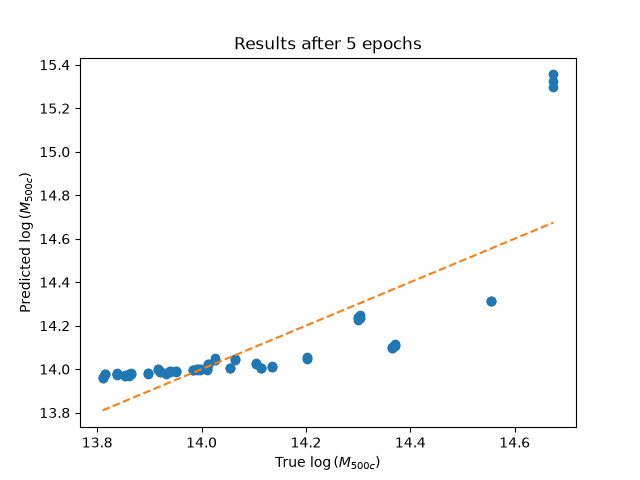

In [8]:
prediction = model.predict(test_X, verbose=0, batch_size=batch_size).flatten()
# Remember when we subtracted off the min in an earlier cell?  In the next line, we're putting it back in!
plt.scatter(test_Y + norm, prediction + norm, c='C0', label='model predictions')
x = np.linspace(np.min(test_Y+norm), np.max(test_Y+norm), 100)
plt.plot(x,x,ls='--', c='C1', label='one-to-one line')
plt.xlabel('True '+r'$\log\left(M_{500c}\right)$')
plt.ylabel('Predicted '+r'$\log\left(M_{500c}\right)$')
plt.title('Results after {:.0f} epochs'.format(epochs))


# Approch 2

## Add cluster aware cross-validation

The following cells convert the FITS metadata to a DataFrame, check cluster completeness, and run cluster-aware cross-validation.

In [6]:
data = {}

table = hdul[2].data

for name in table.names:
    arr = np.array(table[name])

    if arr.dtype.byteorder not in ('=', '|'):
        arr = arr.astype(arr.dtype.newbyteorder('='))

    data[name] = arr

df = pd.DataFrame(data)

### 3. Check cluster completeness

Each complete cluster should contain exactly the three lines of sight: `x`, `y`, and `z`. Incomplete clusters are excluded from cross-validation.

In [7]:
# Verify that every cluster has exactly the three expected lines of sight.
los_by_cluster = df.groupby('cluster_id')['view_los'].agg(lambda values: set(values))
expected_los = set(df['view_los'].dropna().unique())
complete_clusters = los_by_cluster[los_by_cluster == expected_los].index.to_numpy()
incomplete_clusters = los_by_cluster[los_by_cluster != expected_los]

print(f'Expected lines of sight: {sorted(expected_los)}')
print(f'Complete clusters: {len(complete_clusters)} out of {len(los_by_cluster)}')
print('Incomplete or duplicated clusters:')
print(incomplete_clusters)

assert all(len(df[df['cluster_id'] == cid]) == len(expected_los) for cid in complete_clusters), \
    'At least one cluster has duplicate rows for a line of sight.'

Expected lines of sight: ['x', 'y', 'z']
Complete clusters: 328 out of 329
Incomplete or duplicated clusters:
cluster_id
0    {y, z}
Name: view_los, dtype: object


In [8]:
images = hdul[1].data

### 6. Cluster-aware 10-fold cross-validation

The CV loop splits complete `cluster_id` groups, so all three lines of sight remain in the same fold. Cluster 0 is excluded because it is incomplete. Set `epochs` and uncomment `cv_rot` when the rotation-augmented comparison is needed.

In [10]:
n_folds = 10
epochs = 50
batch_size = 16

# `clusters` contains one entry per cluster, not one entry per image.
# Therefore KFold assigns complete cluster IDs to folds.
clusters = np.sort(complete_clusters)
assert len(clusters) >= n_folds

# Store every image row belonging to each cluster. These indices are expanded
# only after the cluster-level fold assignment has been made.
cluster_indices = {
    cid: df.index[df['cluster_id'] == cid].to_numpy()
    for cid in clusters
}
cluster_masses = {
    cid: df.loc[df['cluster_id'] == cid, 'log_M500'].iloc[0]
    for cid in clusters
}
norm_cv = np.nanmin(list(cluster_masses.values()))
cluster_masses = {cid: mass - norm_cv for cid, mass in cluster_masses.items()}

In [25]:
def build_model(with_rotation=False, input_shape=(*images.shape[1:], 1)):
    model_layers = [Input(shape=input_shape)]
    if with_rotation:
        model_layers.extend([
            keras.layers.RandomRotation(0.25),
            keras.layers.RandomFlip('horizontal'),
            keras.layers.RandomFlip('vertical')
        ])
    model_layers.extend([
        Conv2D(16, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Conv2D(32, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        GlobalAveragePooling2D(),
        Dropout(0.1),
        Dense(200, activation='relu'),
        Dropout(0.1),
        Dense(100, activation='relu'),
        Dense(20, activation='relu'),
        Dense(1, activation='linear')
    ])
    model = Sequential(model_layers)
    model.compile(loss='mean_squared_error',
                  optimizer=keras.optimizers.Adam(learning_rate=0.0002),
                  run_eagerly=True,
                  jit_compile=False)
    return model

In [26]:
def run_cv(with_rotation=False):
    folds = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    fold_results = []
    fold_histories = []

    for fold, (train_ids, val_ids) in enumerate(folds.split(clusters), start=1):
        # KFold splits unique cluster IDs, so no cluster can be in both sets.
        train_clusters = clusters[train_ids]
        val_clusters = clusters[val_ids]

        # Expand cluster IDs into image rows only after the split.
        train_indices = np.concatenate([cluster_indices[cid] for cid in train_clusters])
        val_indices = np.concatenate([cluster_indices[cid] for cid in val_clusters])
        train_X = images[train_indices].reshape(-1, *images.shape[1:], 1)
        val_X = images[val_indices].reshape(-1, *images.shape[1:], 1)
        train_Y = np.repeat([cluster_masses[cid] for cid in train_clusters], 3)
        val_Y = np.repeat([cluster_masses[cid] for cid in val_clusters], 3)

        model = build_model(with_rotation=with_rotation)
        history = model.fit(train_X, train_Y,
                            validation_data=(val_X, val_Y),
                            batch_size=batch_size, epochs=epochs, verbose=0)
        predictions = model.predict(val_X, batch_size=batch_size, verbose=0).flatten()
        fold_histories.append(history)
        fold_results.append({
            'fold': fold,
            'r2': r2_score(val_Y, predictions),
            'mae': mean_absolute_error(val_Y, predictions),
            'rmse': np.sqrt(mean_squared_error(val_Y, predictions)),
            'scatter': np.std(val_Y - predictions),
            'bias': np.mean(val_Y - predictions),
            'val_loss': history.history['val_loss'][-1]
        })

    return pd.DataFrame(fold_results), fold_histories

In [36]:
cv_no_rot, histories_no_rot = run_cv(with_rotation=False)
print(cv_no_rot)
print('\n10-fold CV summary:')
print(cv_no_rot[['r2', 'mae', 'rmse', 'scatter', 'bias']].agg(['mean', 'std']))

# Run the augmented comparison when needed:
# cv_rot, histories_rot = run_cv(with_rotation=True)

   fold        r2       mae      rmse   scatter      bias  val_loss
0     1  0.895800  0.050589  0.067915  0.067396 -0.008386  0.004612
1     2  0.852345  0.074874  0.095725  0.081233  0.050640  0.009163
2     3  0.738451  0.081420  0.103782  0.073679  0.073089  0.010771
3     4  0.492377  0.115209  0.134685  0.072618  0.113431  0.018140
4     5  0.875069  0.059316  0.075658  0.075331 -0.007031  0.005724
5     6  0.712340  0.087744  0.102895  0.076139  0.069212  0.010587
6     7  0.924914  0.048568  0.072740  0.072679  0.002994  0.005291
7     8  0.514542  0.137749  0.186258  0.180502  0.045945  0.034692
8     9  0.438175  0.107301  0.196946  0.174899  0.090544  0.038788
9    10  0.395661  0.119863  0.151731  0.127964  0.081532  0.023022

10-fold CV summary:
            r2       mae      rmse   scatter      bias
mean  0.683967  0.088263  0.118834  0.100244  0.051197
std   0.205621  0.030904  0.046639  0.044289  0.042736


### 7. Ten-fold training curves and diagnostics

These plots show whether folds have similar learning behavior and whether performance varies strongly across clusters.

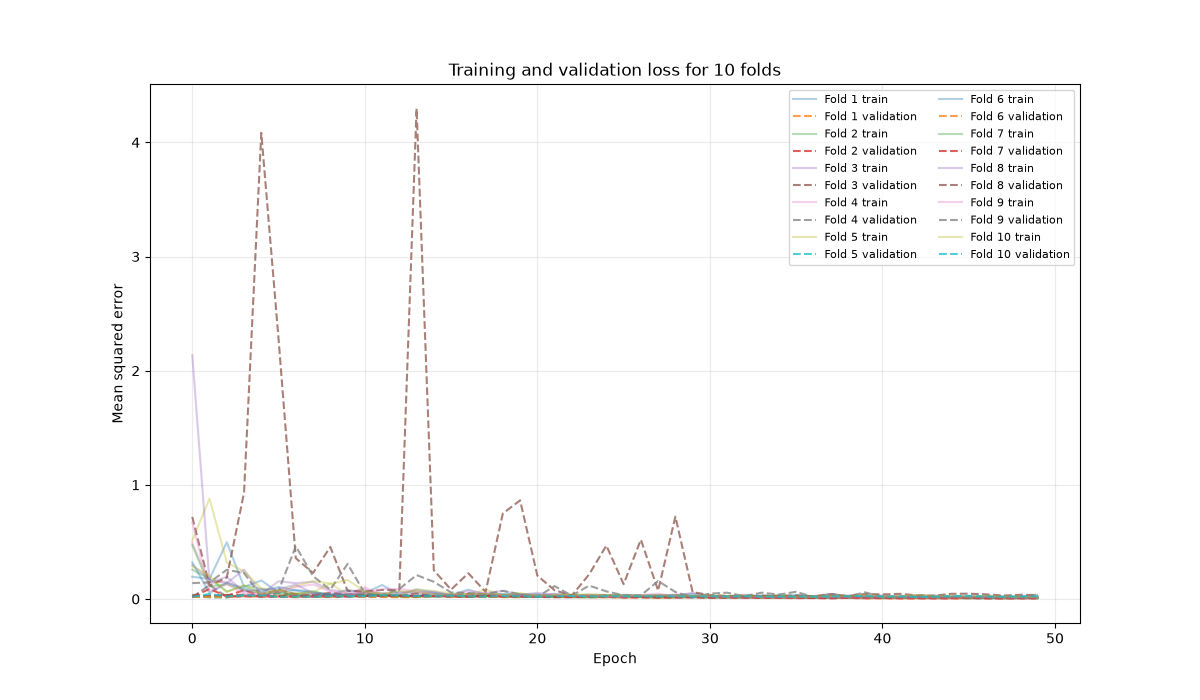

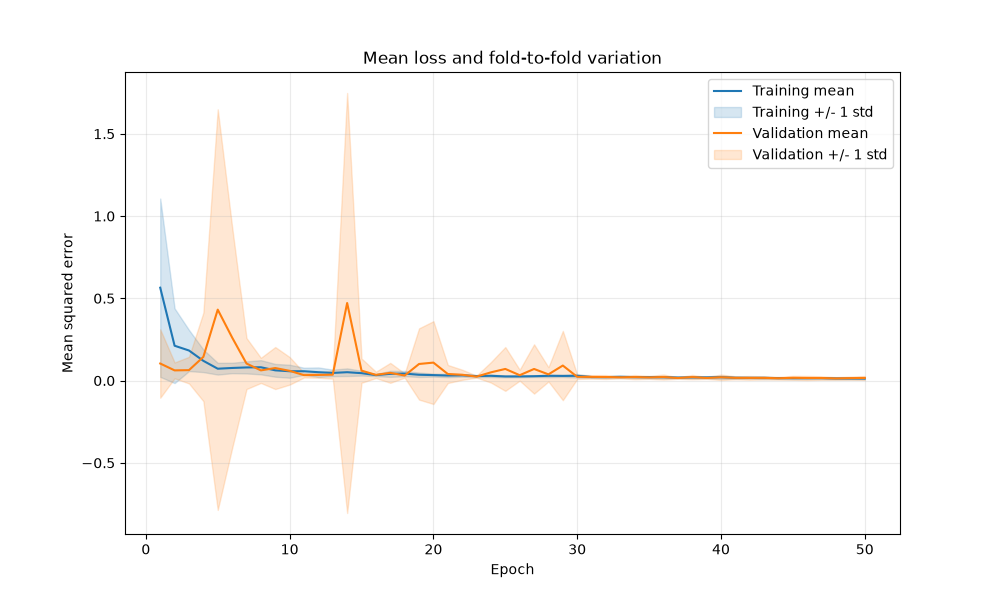

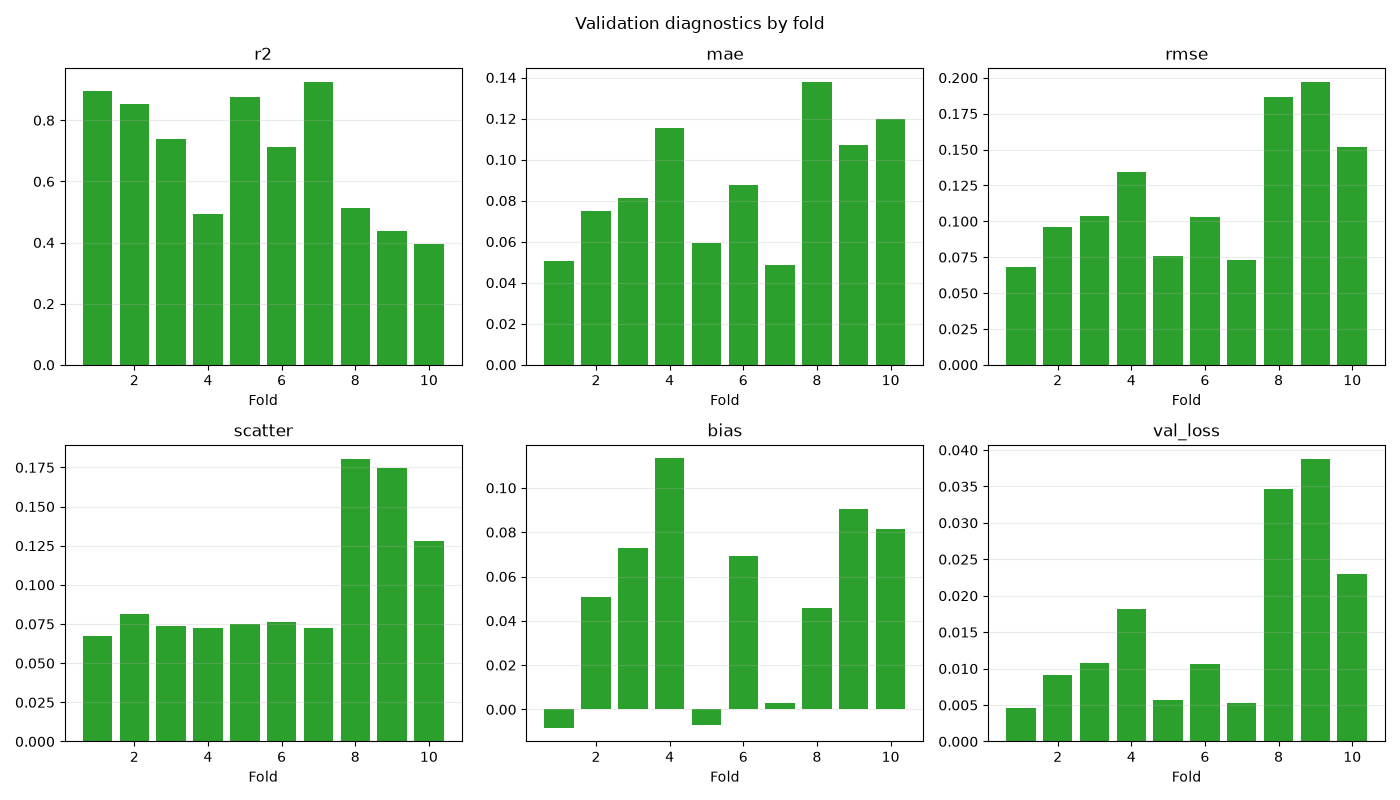

Fold metric summary:


,r2,mae,rmse,scatter,bias,val_loss
mean,0.683967,0.088263,0.118834,0.100244,0.051197,0.016079
std,0.205621,0.030904,0.046639,0.044289,0.042736,0.012364
min,0.395661,0.048568,0.067915,0.067396,-0.008386,0.004612
max,0.924914,0.137749,0.196946,0.180502,0.113431,0.038788


In [37]:
# Plot training and validation loss for every fold.
plt.figure(figsize=(12, 7))
for fold, history in enumerate(histories_no_rot, start=1):
    plt.plot(history.history['loss'], alpha=0.35, label=f'Fold {fold} train')
    plt.plot(history.history['val_loss'], alpha=0.75, linestyle='--', label=f'Fold {fold} validation')
plt.xlabel('Epoch')
plt.ylabel('Mean squared error')
plt.title('Training and validation loss for 10 folds')
plt.grid(alpha=0.25)
plt.legend(ncol=2, fontsize=8)
plt.show()

# Plot mean loss and one-standard-deviation spread across folds.
train_loss = np.array([history.history['loss'] for history in histories_no_rot])
val_loss = np.array([history.history['val_loss'] for history in histories_no_rot])
epoch_axis = np.arange(1, train_loss.shape[1] + 1)

plt.figure(figsize=(10, 6))
for losses, label, color in [(train_loss, 'Training', 'C0'), (val_loss, 'Validation', 'C1')]:
    mean_loss = losses.mean(axis=0)
    std_loss = losses.std(axis=0)
    plt.plot(epoch_axis, mean_loss, color=color, label=f'{label} mean')
    plt.fill_between(epoch_axis, mean_loss - std_loss, mean_loss + std_loss,
                     color=color, alpha=0.18, label=f'{label} +/- 1 std')
plt.xlabel('Epoch')
plt.ylabel('Mean squared error')
plt.title('Mean loss and fold-to-fold variation')
plt.grid(alpha=0.25)
plt.legend()
plt.show()

# Compare final validation metrics across folds.
metrics = ['r2', 'mae', 'rmse', 'scatter', 'bias', 'val_loss']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for axis, metric in zip(axes.flat, metrics):
    axis.bar(cv_no_rot['fold'], cv_no_rot[metric], color='C2')
    axis.set_title(metric)
    axis.set_xlabel('Fold')
    axis.grid(axis='y', alpha=0.25)
plt.suptitle('Validation diagnostics by fold')
plt.tight_layout()
plt.show()

print('Fold metric summary:')
display(cv_no_rot[metrics].agg(['mean', 'std', 'min', 'max']))

# Aproch 3

## Approach 3: Explicit geometric augmentation followed by 10-fold CV

This approach explicitly applies the geometric symmetries of a square image to each original image. We consider the original image, horizontal and vertical flips, and rotations by 90, 180, and 270 degrees. These operations are not all independent: combining a flip with rotations produces the same eight transformations as the dihedral group of the square.

For a generic image, there are at most eight distinct outputs per original image. Therefore, three lines of sight can produce at most `3 x 8 = 24` unique images per cluster. Exact duplicates are removed below, so symmetric images cannot be counted twice.

The folds are assigned using the original cluster IDs before or alongside augmentation. Every augmented copy inherits its source cluster ID and mass, so all copies of a cluster remain in one fold. The CV model uses `with_rotation=False` because the rotations have already been materialized in the dataset; adding Keras `RandomRotation` would apply another, separate augmentation on top of them.

In [27]:
def geometric_variants(image):
    """Return exact unique D4 variants of one square image."""
    candidates = []
    transform_names = []
    for rotation in range(4):
        rotated = np.rot90(image, rotation)
        for flip_name, candidate in [
            ('none', rotated),
            ('horizontal', np.fliplr(rotated)),
            ('vertical', np.flipud(rotated)),
        ]:
            if not any(np.array_equal(candidate, previous) for previous in candidates):
                candidates.append(candidate.copy())
                transform_names.append(f'rot{rotation * 90}_{flip_name}')
    return candidates, transform_names

# Show the redundancy count for one representative cluster.
example_cluster = clusters[0]
example_indices = cluster_indices[example_cluster]
example_counts = []
for source_index in example_indices:
    variants, names = geometric_variants(images[source_index])
    example_counts.append(len(variants))

print(f'Example cluster {example_cluster}: {len(example_indices)} original images')
print(f'Unique variants per image: {example_counts}')
print(f'Unique augmented images in this cluster: {sum(example_counts)}')
assert all(count <= 8 for count in example_counts)
assert sum(example_counts) <= 24

Example cluster 1: 3 original images
Unique variants per image: [8, 8, 8]
Unique augmented images in this cluster: 24


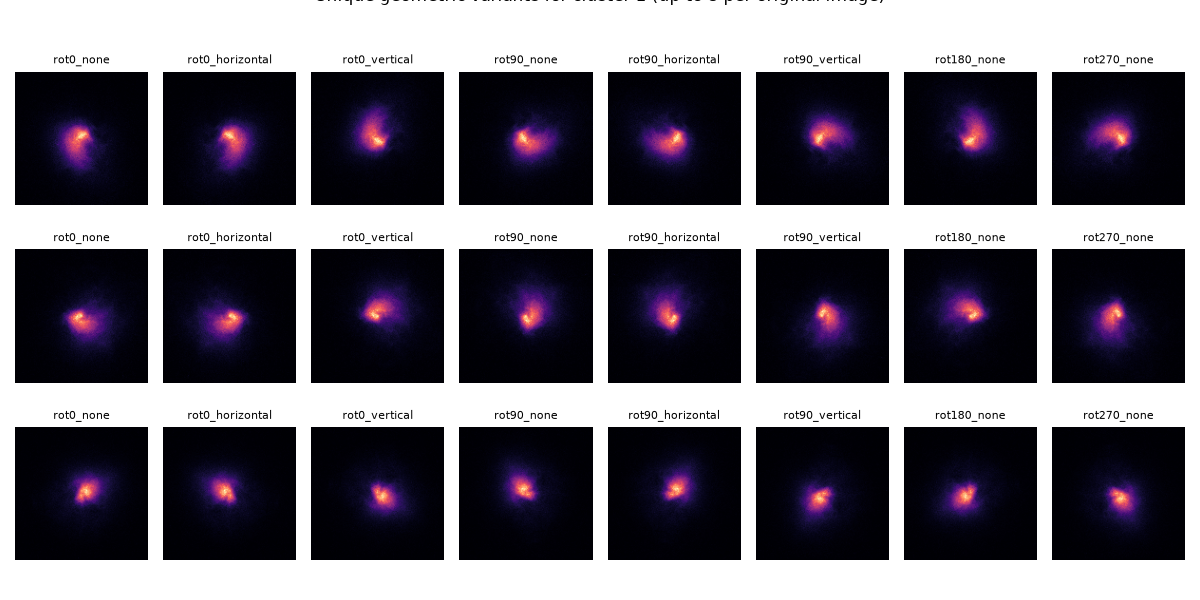

In [28]:
# Display all unique variants for the three original images in one cluster.
fig, axes = plt.subplots(3, 8, figsize=(12, 6))
for row, source_index in enumerate(example_indices):
    variants, names = geometric_variants(images[source_index])
    for column, axis in enumerate(axes[row]):
        axis.axis('off')
        if column < len(variants):
            axis.imshow(variants[column], cmap='magma')
            axis.set_title(names[column], fontsize=8)
    axes[row, 0].set_ylabel(f'LOS {row + 1}', rotation=90, fontsize=10)
plt.suptitle(
    f'Unique geometric variants for cluster {example_cluster} '
    '(up to 8 per original image)',
    y=1.02
)
plt.tight_layout()
plt.show()

### Exampl 2

In [29]:

# Show the redundancy count for one representative cluster.
example_cluster = clusters[5]
example_indices = cluster_indices[example_cluster]
example_counts = []
for source_index in example_indices:
    variants, names = geometric_variants(images[source_index])
    example_counts.append(len(variants))

print(f'Example cluster {example_cluster}: {len(example_indices)} original images')
print(f'Unique variants per image: {example_counts}')
print(f'Unique augmented images in this cluster: {sum(example_counts)}')
assert all(count <= 8 for count in example_counts)
assert sum(example_counts) <= 24

Example cluster 6: 3 original images
Unique variants per image: [8, 8, 8]
Unique augmented images in this cluster: 24


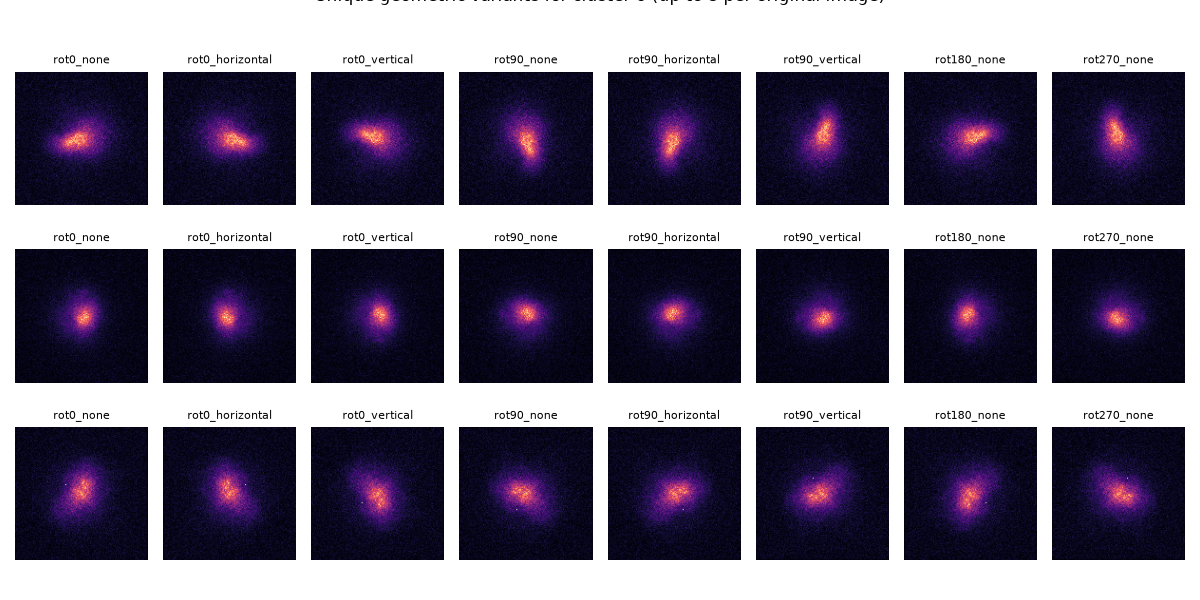

In [30]:
# Display all unique variants for the three original images in one cluster.
fig, axes = plt.subplots(3, 8, figsize=(12, 6))
for row, source_index in enumerate(example_indices):
    variants, names = geometric_variants(images[source_index])
    for column, axis in enumerate(axes[row]):
        axis.axis('off')
        if column < len(variants):
            axis.imshow(variants[column], cmap='magma')
            axis.set_title(names[column], fontsize=8)
    axes[row, 0].set_ylabel(f'LOS {row + 1}', rotation=90, fontsize=10)
plt.suptitle(
    f'Unique geometric variants for cluster {example_cluster} '
    '(up to 8 per original image)',
    y=1.02
)
plt.tight_layout()
plt.show()

### 3. Build the deduplicated augmented dataset

The dataset is augmented cluster by cluster. The source cluster ID is stored for every generated image, which lets cross-validation split on clusters rather than augmented rows. This gives each complete cluster up to 24 images: three original lines of sight times eight unique square-symmetry variants.

In [31]:
augmented_images_list = []
augmented_cluster_ids = []
augmented_masses = []
augmented_transform_names = []

for cluster_id in clusters:
    source_indices = cluster_indices[cluster_id]
    cluster_mass = cluster_masses[cluster_id]
    for source_index in source_indices:
        variants, names = geometric_variants(images[source_index])
        augmented_images_list.extend(variants)
        augmented_cluster_ids.extend([cluster_id] * len(variants))
        augmented_masses.extend([cluster_mass] * len(variants))
        augmented_transform_names.extend(names)

augmented_images = np.stack(augmented_images_list)
augmented_cluster_ids = np.asarray(augmented_cluster_ids)
augmented_masses = np.asarray(augmented_masses)

print(f'Original image rows: {len(images)}')
print(f'Complete-cluster image rows: {sum(len(cluster_indices[cid]) for cid in clusters)}')
print(f'Deduplicated augmented image rows: {len(augmented_images)}')
print(f'Augmented images per complete cluster:')
print(pd.Series(augmented_cluster_ids).value_counts().value_counts().sort_index())

assert set(augmented_cluster_ids) == set(clusters)
assert len(augmented_images) == len(augmented_cluster_ids) == len(augmented_masses)
assert all(
    len(augmented_cluster_ids[augmented_cluster_ids == cluster_id]) <= 24
    for cluster_id in clusters
)

Original image rows: 986
Complete-cluster image rows: 984
Deduplicated augmented image rows: 7872
Augmented images per complete cluster:
count
24    328
Name: count, dtype: int64


### 4. Cluster-level 10-fold CV on the augmented images

The model below uses `build_model(with_rotation=False)`: there is no additional random rotation layer. The explicit rotations and flips are already present in `augmented_images`. Fold assignment is still performed using the original `clusters` array, so no augmented copy of a validation cluster can appear in training.

In [32]:
import time

augmented_indices_by_cluster = {
    cluster_id: np.flatnonzero(augmented_cluster_ids == cluster_id)
    for cluster_id in clusters
}


def run_augmented_cv():
    folds = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    fold_results_augmented = []
    fold_histories_augmented = []
    total_start = time.perf_counter()

    print('Starting augmented-data 10-fold cross-validation')
    print(f'Total complete clusters: {len(clusters)}')
    print(f'Total augmented images: {len(augmented_images)}')
    print(f'Configuration: {n_folds} folds, {epochs} epochs per fold, batch size {batch_size}')
    print('-' * 72)

    for fold, (train_ids, val_ids) in enumerate(folds.split(clusters), start=1):
        fold_start = time.perf_counter()
        train_clusters = clusters[train_ids]
        val_clusters = clusters[val_ids]
        train_indices = np.concatenate(
            [augmented_indices_by_cluster[cluster_id] for cluster_id in train_clusters]
        )
        val_indices = np.concatenate(
            [augmented_indices_by_cluster[cluster_id] for cluster_id in val_clusters]
        )

        train_X_augmented = augmented_images[train_indices].reshape(
            -1, *augmented_images.shape[1:], 1
        )
        val_X_augmented = augmented_images[val_indices].reshape(
            -1, *augmented_images.shape[1:], 1
        )
        train_Y_augmented = augmented_masses[train_indices]
        val_Y_augmented = augmented_masses[val_indices]

        print(
            f'Fold {fold}/{n_folds} starting | '
            f'train: {len(train_clusters)} clusters, {len(train_indices)} images | '
            f'validation: {len(val_clusters)} clusters, {len(val_indices)} images'
        )
        print(f'Fold {fold}: training for {epochs} epochs...')

        model = build_model(
            with_rotation=False,
            input_shape=(*augmented_images.shape[1:], 1)
        )
        history = model.fit(
            train_X_augmented,
            train_Y_augmented,
            validation_data=(val_X_augmented, val_Y_augmented),
            batch_size=batch_size,
            epochs=epochs,
            verbose=1
        )
        predictions = model.predict(
            val_X_augmented,
            batch_size=batch_size,
            verbose=0
        ).flatten()
        residuals = val_Y_augmented - predictions
        fold_histories_augmented.append(history)
        fold_results_augmented.append({
            'fold': fold,
            'r2': r2_score(val_Y_augmented, predictions),
            'mae': mean_absolute_error(val_Y_augmented, predictions),
            'rmse': np.sqrt(mean_squared_error(val_Y_augmented, predictions)),
            'scatter': np.std(residuals),
            'bias': np.mean(residuals),
            'val_loss': history.history['val_loss'][-1],
            'train_images': len(train_indices),
            'val_images': len(val_indices)
        })
        fold_result = fold_results_augmented[-1]
        fold_elapsed = time.perf_counter() - fold_start
        print(
            f"Fold {fold}/{n_folds} complete in {fold_elapsed / 60:.1f} min | "
            f"R2={fold_result['r2']:.4f}, "
            f"MAE={fold_result['mae']:.4f}, "
            f"RMSE={fold_result['rmse']:.4f}, "
            f"val_loss={fold_result['val_loss']:.6f}"
        )
        print(f'Elapsed total: {(time.perf_counter() - total_start) / 60:.1f} min')
        print('-' * 72)

    print(
        f'Augmented 10-fold CV finished in '
        f'{(time.perf_counter() - total_start) / 60:.1f} min'
    )
    return pd.DataFrame(fold_results_augmented), fold_histories_augmented

In [ ]:
cv_augmented, histories_augmented = run_augmented_cv()
print('Approach 3: explicit geometric augmentation + cluster-level 10-fold CV')
display(cv_augmented)
print('Output matrix summary:')
display(cv_augmented[
    ['r2', 'mae', 'rmse', 'scatter', 'bias', 'val_loss']
].agg(['mean', 'std', 'min', 'max']))

Starting augmented-data 10-fold cross-validation
Total complete clusters: 328
Total augmented images: 7872
Configuration: 10 folds, 50 epochs per fold, batch size 16
------------------------------------------------------------------------
Fold 1/10 starting | train: 295 clusters, 7080 images | validation: 33 clusters, 792 images
Fold 1: training for 50 epochs...
Epoch 1/50
443/443 ━━━━━━━━━━━━━━━━━━━━ 20s 44ms/step - loss: 0.1202 - val_loss: 0.0252
Epoch 2/50
443/443 ━━━━━━━━━━━━━━━━━━━━ 20s 45ms/step - loss: 0.0416 - val_loss: 0.0205
Epoch 3/50
443/443 ━━━━━━━━━━━━━━━━━━━━ 20s 45ms/step - loss: 0.0347 - val_loss: 0.0170
Epoch 4/50
443/443 ━━━━━━━━━━━━━━━━━━━━ 20s 45ms/step - loss: 0.0262 - val_loss: 0.0138
Epoch 5/50
443/443 ━━━━━━━━━━━━━━━━━━━━ 20s 45ms/step - loss: 0.0218 - val_loss: 0.0102
Epoch 6/50
443/443 ━━━━━━━━━━━━━━━━━━━━ 20s 45ms/step - loss: 0.0157 - val_loss: 0.0069
Epoch 7/50
443/443 ━━━━━━━━━━━━━━━━━━━━ 20s 45ms/step - loss: 0.0128 - val_loss: 0.0055
Epoch 8/50
443/443 